In [32]:
# from bpe import train_bpe
# import time
# start = time.perf_counter()

# special_tokens = ["<|endoftext|>"]
# input_path = "../data/sample.txt"
# vocab_size = 260

# vocab, merge = train_bpe(input_path, vocab_size, special_tokens)

# end = time.perf_counter()
# print(f"spend {end - start:.5f} seconds")

In [33]:
# from bpe import train_bpe
# import time
# start = time.perf_counter()

# special_tokens = ["<|endoftext|>"]
# input_path = "../data/TinyStoriesV2-GPT4-valid.txt"
# vocab_size = 1000

# vocab, merge = train_bpe(input_path, vocab_size, special_tokens)

# end = time.perf_counter()
# print(f"spend {end - start:.5f} seconds")

In [19]:
# from bpe import train_bpe
# import time
# start = time.perf_counter()

# special_tokens = ["<|endoftext|>"]
# input_path = "../data/TinyStoriesV2-GPT4-train.txt"
# vocab_size = 1000

# vocab, merge = train_bpe(input_path, vocab_size, special_tokens)

# end = time.perf_counter()
# print(f"spend {end - start:.5f} seconds")

In [42]:
from cs336_basics.pretokenization_example import find_chunk_boundaries
import regex as re
input_path = "../data/TinyStoriesV2-GPT4-train.txt"
split_chunks = []
special_tokens = ["<|endoftext|>"]
with open(input_path, "rb") as f:
    num_processes = 100000
    boundaries = find_chunk_boundaries(f, num_processes, b"<|endoftext|>")
    for start, end in zip(boundaries[:-1], boundaries[1:]):
        f.seek(start)
        chunk = f.read(end - start).decode("utf-8", errors="ignore")
        # Run pre-tokenization on your chunk and store the counts for each pre-token
        pattern = "|".join(re.escape(tok) for tok in special_tokens)
        split_chunk = re.split(pattern, chunk)
        # split_chunk is a list of paragraph or list of story
        split_chunks += split_chunk

In [43]:
len(split_chunks)

2817699

In [44]:
xx = [len(x) for x in split_chunks]

In [46]:
xx.index(5499)

1072534

In [47]:
split_chunks[1072534]

'\n\n\nLily and Ben were friends. They liked to play with toys and run in the park. One day, they found a big cake on the table. It looked yummy and sweet. They wanted to eat some.\nBut Mom said, "No, no, no. That cake is for Grandma\'s birthday. You can\'t have any. It is not for you."\nLily and Ben were sad and angry. They did not like Mom\'s words. They did not want to wait for Grandma. They wanted cake now.\nThey had a bad idea. They decided to sneak some cake when Mom was not looking. They took a big knife and cut a slice. They put it on a plate and ran to the corner.\nThey took a bite of the cake. But it was not yummy and sweet. It was disgusting and bitter. It had salt and pepper and vinegar and mustard and garlic and onion and cheese and fish and pickle and soap and dirt and bugs and worms and hair and nails and glass and metal and rocks and sticks and bones and blood and poop and pee and spit and snot and pus and vomit and slime and goo and mold and rot and rust and dust and a

In [48]:
with open("output.txt", "w") as f:
    f.write(split_chunks[1072534])

In [41]:
len(xx)

2727699

(array([1.02190e+04, 2.00000e+01, 1.30000e+01, 2.00000e+01, 6.30000e+01,
        6.39000e+02, 4.22700e+03, 1.97570e+04, 6.67540e+04, 1.62473e+05,
        2.85507e+05, 3.69526e+05, 3.88140e+05, 3.41619e+05, 2.65676e+05,
        1.94278e+05, 1.38410e+05, 9.67890e+04, 6.65430e+04, 4.62230e+04,
        3.37250e+04, 2.61110e+04, 2.10710e+04, 1.70630e+04, 1.48650e+04,
        1.36120e+04, 1.29460e+04, 1.20600e+04, 1.15110e+04, 1.06890e+04,
        9.87600e+03, 9.27000e+03, 8.45600e+03, 7.64800e+03, 6.89500e+03,
        6.12700e+03, 5.65000e+03, 4.91200e+03, 4.40200e+03, 3.99300e+03,
        3.50000e+03, 3.09200e+03, 2.70300e+03, 2.46100e+03, 2.09000e+03,
        1.90600e+03, 1.60200e+03, 1.41800e+03, 1.25700e+03, 1.08200e+03,
        9.84000e+02, 9.35000e+02, 7.42000e+02, 6.61000e+02, 5.95000e+02,
        5.19000e+02, 4.80000e+02, 3.93000e+02, 3.63000e+02, 3.12000e+02,
        2.67000e+02, 2.50000e+02, 2.26000e+02, 1.91000e+02, 1.98000e+02,
        1.66000e+02, 1.74000e+02, 1.93000e+02, 1.91

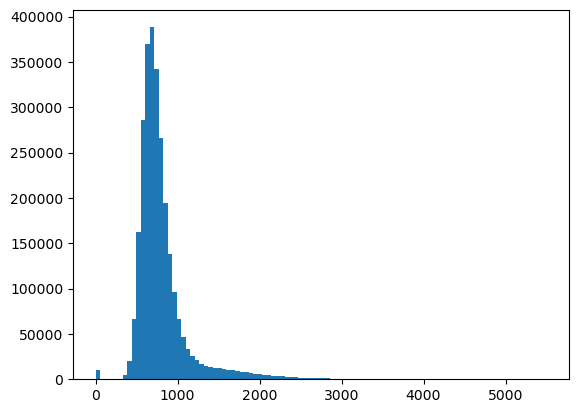

In [40]:
import matplotlib.pyplot as plt
plt.hist(xx, bins = 100)

In [29]:
PAT = r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
def pretokenize(chunk):
    return re.findall(PAT, chunk)

In [31]:
import multiprocessing as mp
from tqdm import tqdm
def pretokenize(chunk):
    # TODO: your logic
    return chunk

def run(chunks, *, workers=None, chunksize=64):
    workers = workers or mp.cpu_count()
    with mp.get_context("spawn").Pool(processes=workers) as pool:
        it = pool.imap_unordered(pretokenize, chunks, chunksize=chunksize)
        return list(tqdm(it, total=len(chunks)))

chunks = split_chunks[:100]
outputs = run(chunks, workers=None, chunksize=128)

Process SpawnPoolWorker-1478:
Traceback (most recent call last):
  0%|          | 0/100 [00:00<?, ?it/s]  File "/Users/hous/miniconda3/envs/llm/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/hous/miniconda3/envs/llm/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/hous/miniconda3/envs/llm/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/Users/hous/miniconda3/envs/llm/lib/python3.12/multiprocessing/queues.py", line 389, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'pretokenize' on <module '__main__' (<class '_frozen_importlib.BuiltinImporter'>)>
Process SpawnPoolWorker-1484:
Process SpawnPoolWorker-1485:
Process SpawnPoolWorker-1481:
Process SpawnPoolWorker-1483:
Process SpawnPoolWorker-1479:
  0%|          | 0/100 [00:09<?, ?it/s]Process

KeyboardInterrupt: 

In [ ]:
import multiprocessing
PAT = r"""'(?:[sdmt]|ll|ve|re)| ?\p{L}+| ?\p{N}+| ?[^\s\p{L}\p{N}]+|\s+(?!\S)|\s+"""
def pretokenize(chunk):
    return re.findall(PAT, chunk)
with multiprocessing.Pool() as pool:
    pretokenized_split_chunk = pool.map(pretokenize, split_chunks[:10])

Process SpawnPoolWorker-1451:
Process SpawnPoolWorker-1452:
Process SpawnPoolWorker-1453:
Process SpawnPoolWorker-1455:
Process SpawnPoolWorker-1454:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/hous/miniconda3/envs/llm/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/Users/hous/miniconda3/envs/llm/lib/python3.12/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/hous/miniconda3/envs/llm/lib/python3.12/multiprocessing/pool.py", line 114, in worker
    task = get()
           ^^^^^
  File "/Users/hous/miniconda3/envs/llm/lib/python3.12/multiprocessing/queues.py", line 389, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: Can't get attribute 'pretokenize' on <module '__main__' (<class '_frozen_impor

KeyboardInterrupt: 

In [ ]:



def train_bpe(input_path, vocab_size, special_tokens):
    merge = []
    vocab = [bytes([i]) for i in range(256)]
    vocab += [s.encode("utf-8") for s in special_tokens]

    print("Pretokening .......")
    token_counter = defaultdict(int)
    with open(input_path, "rb") as f:
        num_processes = 64
        boundaries = find_chunk_boundaries(f, num_processes, b"<|endoftext|>")
        # The following is a serial implementation, but you can parallelize this
        # by sending each start/end pair to a set of processes.
        for start, end in zip(boundaries[:-1], boundaries[1:]):
            f.seek(start)
            chunk = f.read(end - start).decode("utf-8", errors="ignore")
            # Run pre-tokenization on your chunk and store the counts for each pre-token
            pattern = "|".join(re.escape(tok) for tok in special_tokens)
            split_chunk = re.split(pattern, chunk)
            # split_chunk is a list of paragraph or list of story
            with multiprocessing.Pool() as pool:
                pretokenized_split_chunk = pool.map(pretokenize, split_chunk)
            for tokens in pretokenized_split_chunk:
                for token in tokens:
                    utf8_encoded = token.encode("utf-8")
                    key = tuple(
                        bytes([x]) for x in utf8_encoded
                    )  # key is a tuple of bytes
                    token_counter[key] += 1